## 검색도구를 활용하는 플래너 랭그래프 실습

In [67]:
from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate
from typing import Annotated, TypedDict, Literal, List
from langgraph.graph.message import add_messages
from langgraph.graph import StateGraph, START, END
# 도구
from langgraph.prebuilt.tool_node import ToolNode, tools_condition
from langchain_tavily import TavilySearch
# 그래프 프롬프트 메시지
from langchain_core.messages import SystemMessage, HumanMessage, BaseMessage, AIMessage

import operator

### 노드가 주고받을 상태(State) 정의

In [97]:
# state 정의
class State(TypedDict):
    # 모델 입출력
    messages: Annotated[List[BaseMessage], operator.add]

    # 현재 그래프가 진행중인 단계
    status: Literal["planning", "acting", "replanning", "reporting", 'done']

    # 최종 리포트
    report: str

### 도구 세팅

In [69]:
# 도구 세팅
search_tool = TavilySearch(max_result = 5)
tools = [search_tool]

### 모델 세팅

In [70]:
# 모델 세팅
llm_plan = ChatOpenAI(
    model="gpt-4.1-mini",
    temperature=0
)

llm_agent = ChatOpenAI(
    model="gpt-4o",
    temperature=0
)

### 그래프에 필요한 노드 생성

In [ ]:
# planner 노드

plan_system = """
당신은 아주 똑똑한 플래너야. IQ가 240이야. 당신은 일처리를 계획적이고 효율적으로 진행한다.
목표를 달성할 수 있도록 단계적 계획을 5 ~ 7 단계로 작성해.
- 각 단계: 목적/행동/산출물/기간/도구필요여부 한줄 요약

"""
def planner_node(state: State):
    print("--- 💡 플래너 노드 실행 ---")

    # 1. 지시사항을 프롬프트를 SystemMessage 객체로 만듦
    system_prompt = SystemMessage(content=plan_system)

    # 2. state의 messages 리스트에서 가장 마지막 메시지(사용자의 목표)를 가져옴
    user_goal = state["messages"][-1]

    # 3. LLM에 [지시사항, 사용자 목표]를 함께 전달
    messages_for_llm = [system_prompt, user_goal]

    # 4. LLM을 호출하여 계획을 생성합니다.
    # answer는 AIMessage 객체가 됩니다.
    answer = llm_plan.invoke(messages_for_llm)

    # 5. 상태를 업데이트
    return {**state, "messages": [answer], "status": "planning"}

In [72]:
# agent 노드
agent_chatbot = llm_agent.bind_tools(tools=tools)

def agent_node(state: State):
    answer = agent_chatbot.invoke(state["messages"])
    return {**state, "messages":[answer], "status": "acting"}

In [73]:
# tool 노드
tool_node = ToolNode(tools)

In [74]:
# 리플랜 노드
replan_system = (
    "당신은 리플래너입니다. 직전 도구/에이전트 결과를 분석해서 다음 행동을 지시하세요."
    "충분한 근거가 모였다면, '종료'를 선언"
    "아니면 다음 검색/행동을 지시하세요."
)
def replan_node(state: State):
    print("--- 💡 리플랜 노드 실행 ---")

    # 1. 리플랜 지시사항을 SystemMessage 객체로 만듭니다.
    system_prompt = SystemMessage(content=replan_system)

    # 2. LLM에 [지시사항] + [전체 대화 기록]을 함께 전달합니다.
    # 이렇게 해야 LLM이 '원래 목표'와 '지금까지의 과정'을 모두 알 수 있음 
    messages_for_llm = [system_prompt] + state["messages"]

    # 3. LLM을 호출하여 '다음 계획' 또는 종료를 결정
    answer = llm_plan.invoke(messages_for_llm)

    # 4. 상태를 업데이트
    return {**state, "messages": [answer], "status": "replanning"}

In [75]:
# 마지막 리포트 노드

report_system = (
    "지금까지 대화/검색 내용을 바탕으로 최종 리포트를 작성하세요."
    "핵심 포인트 -> 리스크 / 기회 -> 참고 자료 요약\n"
)

def report_node(state: State) -> State:
    print("--- 💡 리포트 노드 실행 ---")

    # 1. 리포트 지시사항을 SystemMessage 객체로 만듭니다.
    system_prompt = SystemMessage(content=report_system)

    # 2. LLM에 [지시사항] + [전체 대화 기록]을 함께 전달합니다.
    messages_for_llm = [system_prompt] + state["messages"]

    # 3. llm을 호출하여 지금까지의 계획을 리포트로 작성
    answer = llm_plan.invoke(messages_for_llm)

    # 4. 상태 업데이트
    return {**state, "messages": [answer], "report": answer.content, "status": "reporting"}



### 그래프 빌더 생성

In [76]:
from langgraph.graph import StateGraph, START, END

graph_builder = StateGraph(State)

### 그래프에 노드 주입

In [77]:
graph_builder.add_node("planner", planner_node)
graph_builder.add_node("agent", agent_node)
graph_builder.add_node("tools", tool_node)
graph_builder.add_node("replan", replan_node)
graph_builder.add_node("report", report_node)

### 고정 엣지 추가

In [78]:
# 고정 엣지 추가
graph_builder.add_edge(START, "planner")
graph_builder.add_edge("planner", "agent")
graph_builder.add_edge("tools", "replan")
graph_builder.add_edge("report", END)

### 조건 분기 함수와 조건부 엣지 추가

In [79]:
def route_agent(state: State):
    """ 
    agent 노드 이후 실행.
    tool_calls가 마지막 메시지에 있으면 'tools'로 없으면 'report'로 라우팅
    """
    if state['messages'][-1].tool_calls:
        return "tools"
    else:
        return "report"
    
# agent 노드에서 시작하는 조건부 엣지
graph_builder.add_conditional_edges(
    "agent", route_agent, {"tools": "tools", "report": "report"}
)

In [80]:
def route_replan(state: State):
    """ 
    replan 노드 이후 실행.
    마지막 메시지에 '종료'가 포함되면 'report'로 없으면 'agent'로 라우팅
    """
    last_message = state['messages'][-1].content.lower()
    if '종료' in last_message or '완료' in last_message:
        return "report"
    else:
        return "agent"
    
graph_builder.add_conditional_edges(
    "replan", route_replan, {"report": "report", "agent": "agent"}
)

### 그래프 컴파일, 구조 출력

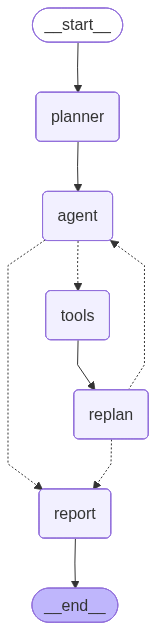

In [81]:
graph = graph_builder.compile()
graph

### 그래프 실행

In [95]:
question = "다음 주말에 부산으로 1박 2일 여행을 가려고 해. KTX 시간표를 검색하고, 해운대 근처 4성급 호텔 3곳을 추천해 줘."
for event in graph.stream({"messages": [HumanMessage(content=question)]}, stream_mode="values"):
    for key, value in event.items():
        print("-"*30, key, "-"*30)
        
        if key == "messages" and value:
            value[-1].pretty_print()
        else:
            # 'status', 'report' 등 다른 키들은 그냥 값을 출력
            print(value)

------------------------------ messages ------------------------------
================================ Human Message =================================

다음 주말에 부산으로 1박 2일 여행을 가려고 해. KTX 시간표를 검색하고, 해운대 근처 4성급 호텔 3곳을 추천해 줘.
--- 💡 플래너 노드 실행 ---
------------------------------ messages ------------------------------
================================== Ai Message ==================================

1. 목적: KTX 부산행 시간 확인  
   행동: 코레일 홈페이지 또는 앱에서 서울-부산 KTX 시간표 검색  
   산출물: 출발 및 도착 시간 리스트  
   기간: 10분  
   도구필요여부: 인터넷 연결 필요  

2. 목적: 여행 일정 계획 수립  
   행동: KTX 시간에 맞춰 출발 및 도착 시간 결정  
   산출물: 여행 출발 및 귀가 시간 확정  
   기간: 5분  
   도구필요여부: 없음  

3. 목적: 해운대 4성급 호텔 후보 선정  
   행동: 호텔 예약 사이트(예: 호텔스닷컴, 아고다)에서 해운대 4성급 호텔 검색  
   산출물: 호텔 후보 5곳 리스트  
   기간: 15분  
   도구필요여부: 인터넷 연결 필요  

4. 목적: 호텔 후보 평가 및 3곳 추천  
   행동: 가격, 위치, 후기 점수 비교 후 최적 3곳 선정  
   산출물: 추천 호텔 3곳 리스트  
   기간: 10분  
   도구필요여부: 없음  

5. 목적: 최종 여행 계획 정리  
   행동: KTX 시간과 호텔 정보를 한 문서 또는 메모에 정리  
   산출물: 완성된 여행 계획표  
   기간: 5분  
   도구필요여부: 없음  

---



In [85]:
result = graph.invoke({"messages": [HumanMessage(content=question)]})

--- 💡 플래너 노드 실행 ---
--- 💡 리플랜 노드 실행 ---
--- 💡 리포트 노드 실행 ---


In [91]:
print(result["report"])

1. KTX 서울-부산 시간표는 코레일 공식 홈페이지(https://www.letskorail.com/)에서 확인 가능합니다. 출발역과 도착역, 날짜를 입력해 원하는 시간대 열차를 조회하세요.

2. 해운대 근처 4성급 호텔 추천 3곳:
- L7 해운대 바이 롯데: 해운대구 중심에 위치, 모던한 시설과 좋은 평점 보유
- 베스트 웨스턴 해운대 호텔: 해운대 해변과 가까우며 개인 주차장 등 편의시설 완비
- 신라스테이 해운대: 해운대 중심부에 위치, 고급스러운 객실과 접근성 우수

이 호텔들은 해운대 관광에 최적이며, 예약 사이트에서 가격과 후기를 확인 후 예약하시길 권장합니다.
